In [1]:
import zipfile
import os
import pandas as pd

# 1. Unzip the uploaded archive (1).zip file
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# 2. List extracted files to check the exact CSV filename
extracted_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("Extracted CSV files:", extracted_files)

# 3. Load the CSV (using the first extracted CSV file)
csv_filename = extracted_files[0]
df = pd.read_csv(csv_filename)

# Display data overview
print("\nDataFrame Shape:", df.shape)
df.head()

BadZipFile: File is not a zip file

In [2]:
import pandas as pd

# Load directly if it's already an uncompressed file or standard CSV
df = pd.read_csv('archive (1).zip')

print("DataFrame Shape:", df.shape)
df.head()

BadZipFile: File is not a zip file

In [3]:
import zipfile
import os
import pandas as pd

# Unzip the uploaded file
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Find and load the extracted CSV
extracted_files = [f for f in os.listdir('.') if f.endswith('.csv')]
df = pd.read_csv(extracted_files[0])

# Check data
print("DataFrame Shape:", df.shape)
df.head()

IndexError: list index out of range

Total .tif files found: 356
First 5 files: ['NDWI_2024-10-23.tif', 'SWIR_2024-09-18.tif', 'FalseColor_2025-04-21.tif', 'TCI_2025-09-10.tif', 'SWIR_2025-04-26.tif']

--- Image Metadata ---
File: NDWI_2024-10-23.tif
Width x Height: 317 x 334
Bands: 1
CRS: EPSG:32643


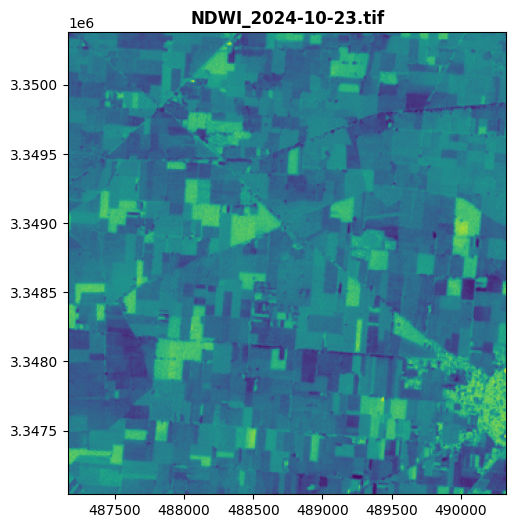

In [4]:
!pip install rasterio matplotlib

import os
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# 1. Get all extracted .tif files
tif_files = [f for f in os.listdir('.') if f.endswith('.tif')]
print(f"Total .tif files found: {len(tif_files)}")
print("First 5 files:", tif_files[:5])

# 2. Open and display the first image
sample_file = tif_files[0]
with rasterio.open(sample_file) as src:
    print("\n--- Image Metadata ---")
    print(f"File: {sample_file}")
    print(f"Width x Height: {src.width} x {src.height}")
    print(f"Bands: {src.count}")
    print(f"CRS: {src.crs}")

    # Plot the image
    plt.figure(figsize=(8, 6))
    show(src, title=sample_file, cmap='viridis')
    plt.show()

In [5]:
import os
import re
import rasterio
import pandas as pd

data = []

# Loop over all .tif files and extract index, date, and mean value
for filename in os.listdir('.'):
    if filename.endswith('.tif'):
        # Parse index type and date from filename (e.g. NDVI_2024-10-23.tif)
        parts = filename.replace('.tif', '').split('_')
        if len(parts) >= 2:
            index_type = parts[0]
            date_str = parts[1].split('(')[0]  # strip duplicate tags like (1)

            with rasterio.open(filename) as src:
                arr = src.read(1)
                mean_val = arr.mean()
                max_val = arr.max()
                min_val = arr.min()

            data.append({
                'filename': filename,
                'index_type': index_type,
                'date': pd.to_datetime(date_str, errors='coerce'),
                'mean': mean_val,
                'min': min_val,
                'max': max_val
            })

# Convert to DataFrame
df_raster = pd.DataFrame(data).dropna(subset=['date']).sort_values('date')
df_raster.head()

,filename,index_type,date,mean,min,max
171,NDVI_2022-01-02.tif,NDVI,2022-01-02,NaN,NaN,NaN
176,FalseColor_2024-04-16.tif,FalseColor,2024-04-16,3530.989356,0.0,6556.0
355,NDVI_2024-04-21.tif,NDVI,2024-04-21,NaN,NaN,NaN
141,NDSI_2024-04-21.tif,NDSI,2024-04-21,NaN,NaN,NaN
160,TCI_2024-04-21.tif,TCI,2024-04-21,186.496080,0.0,255.0


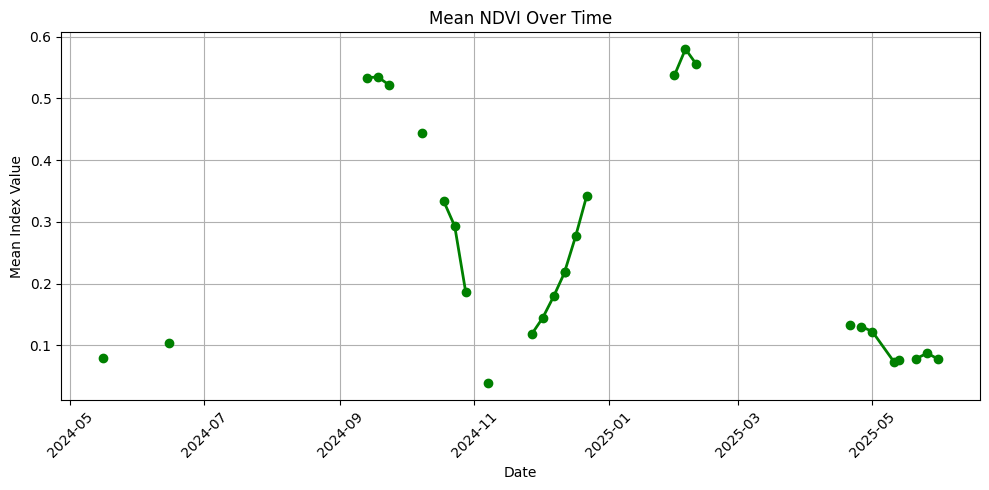

In [6]:
import matplotlib.pyplot as plt

# Filter for NDVI index
ndvi_df = df_raster[df_raster['index_type'] == 'NDVI'].sort_values('date')

plt.figure(figsize=(10, 5))
plt.plot(ndvi_df['date'], ndvi_df['mean'], marker='o', color='green', linewidth=2)
plt.title('Mean NDVI Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Index Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

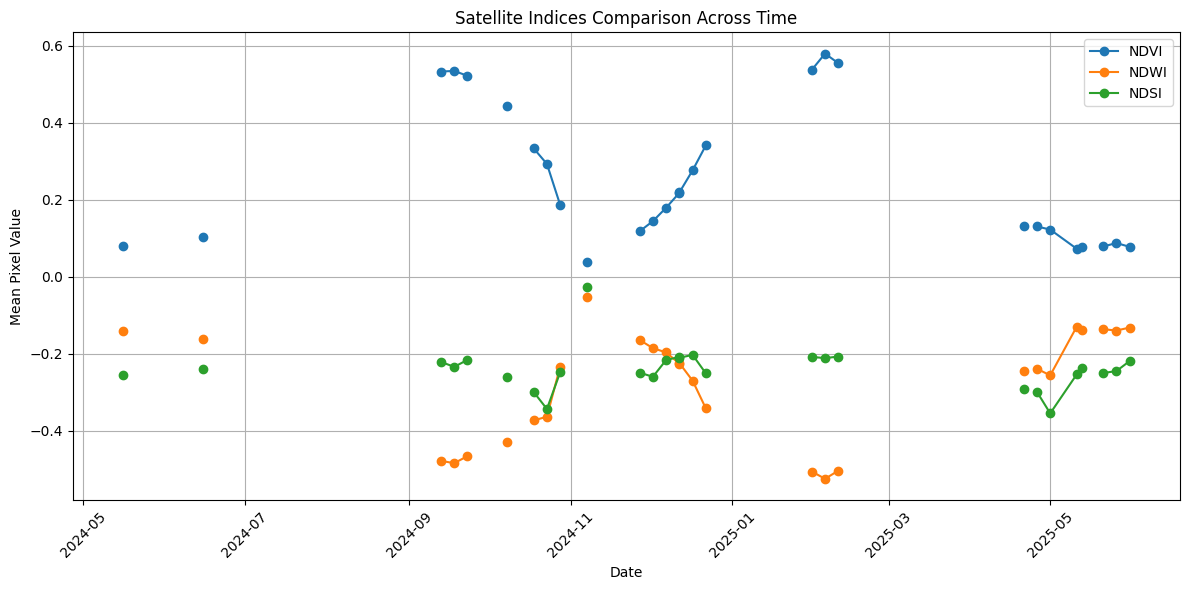

In [7]:
plt.figure(figsize=(12, 6))

for idx_name in ['NDVI', 'NDWI', 'NDSI']:
    sub_df = df_raster[df_raster['index_type'] == idx_name].sort_values('date')
    if not sub_df.empty:
        plt.plot(sub_df['date'], sub_df['mean'], marker='o', label=idx_name)

plt.title('Satellite Indices Comparison Across Time')
plt.xlabel('Date')
plt.ylabel('Mean Pixel Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
 # Pivot metrics so each index is a column by date
pivoted_df = df_raster.pivot(index='date', columns='index_type', values='mean')
pivoted_df.to_csv('time_series_satellite_summary.csv')
print("Saved summary table to time_series_satellite_summary.csv")
pivoted_df.head()

ValueError: Index contains duplicate entries, cannot reshape

In [9]:
# Pivot to create a clean matrix of dates vs satellite indices
pivoted_df = df_raster.pivot_table(
    index='date',
    columns='index_type',
    values='mean',
    aggfunc='mean'
)

# Display summary matrix
print("Reshaped Summary Table:")
pivoted_df.head()

Reshaped Summary Table:


index_type,FalseColor,NDSI,NDVI,NDWI,SWIR,TCI
date,,,,,,
2024-04-16,3530.989356,NaN,NaN,NaN,NaN,NaN
2024-04-21,3641.078675,NaN,NaN,NaN,4279.204122,186.496080
2024-04-26,3996.267742,NaN,NaN,NaN,4813.711007,217.421362
2024-05-01,3934.594514,NaN,NaN,NaN,4642.141446,214.729424
2024-05-06,3622.107378,NaN,NaN,NaN,4512.800204,197.246076


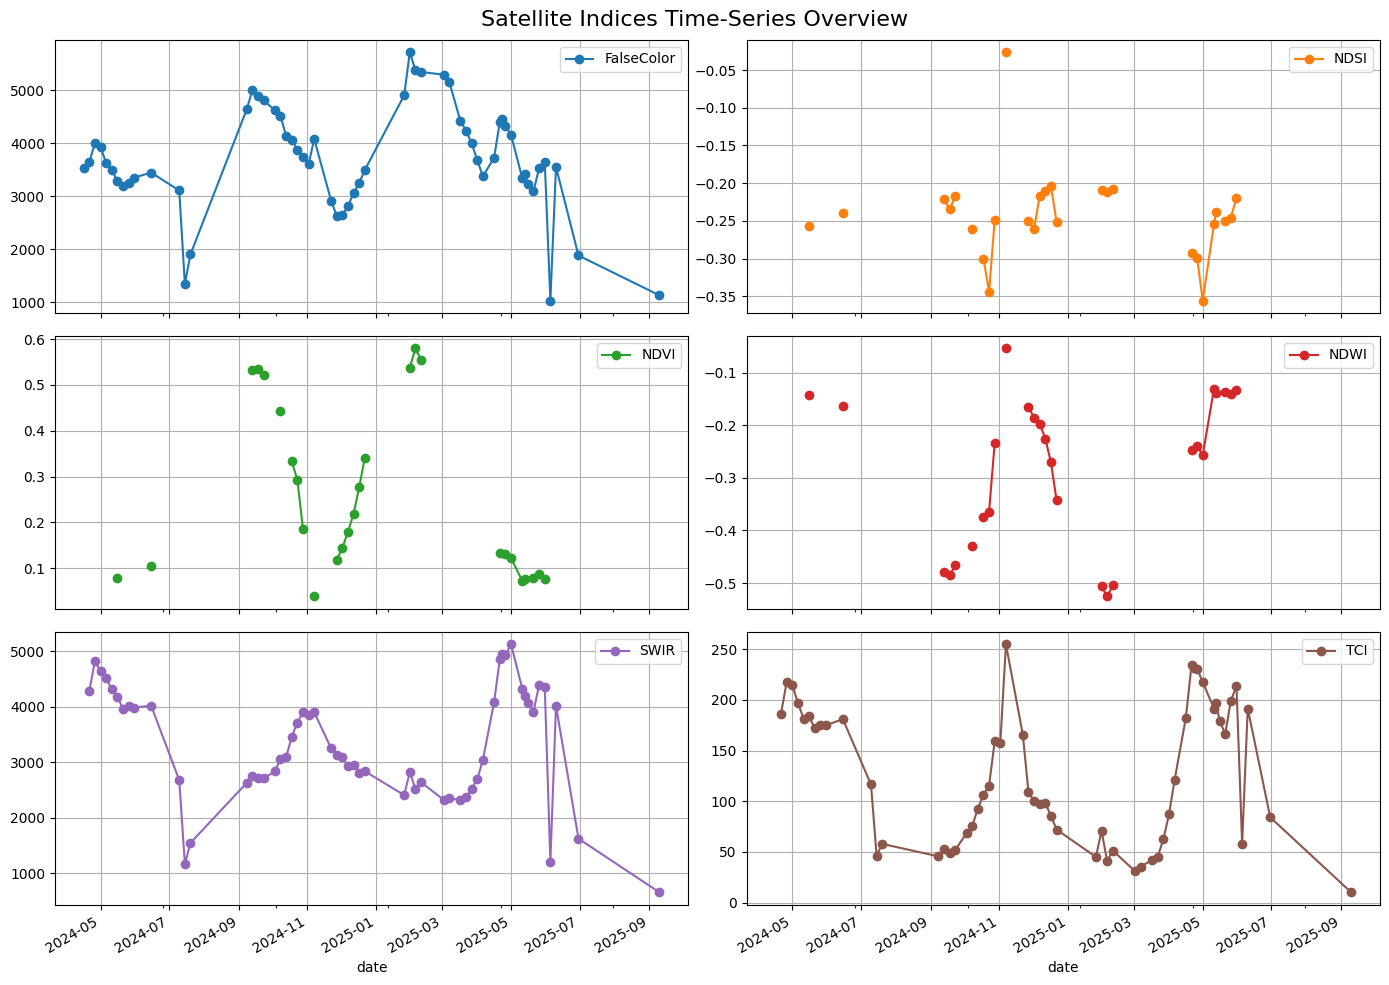

In [10]:
import matplotlib.pyplot as plt

# Plot subplots for each satellite index
pivoted_df.plot(
    subplots=True,
    layout=(3, 2),
    figsize=(14, 10),
    marker='o',
    grid=True
)

plt.suptitle('Satellite Indices Time-Series Overview', fontsize=16)
plt.tight_layout()
plt.show()

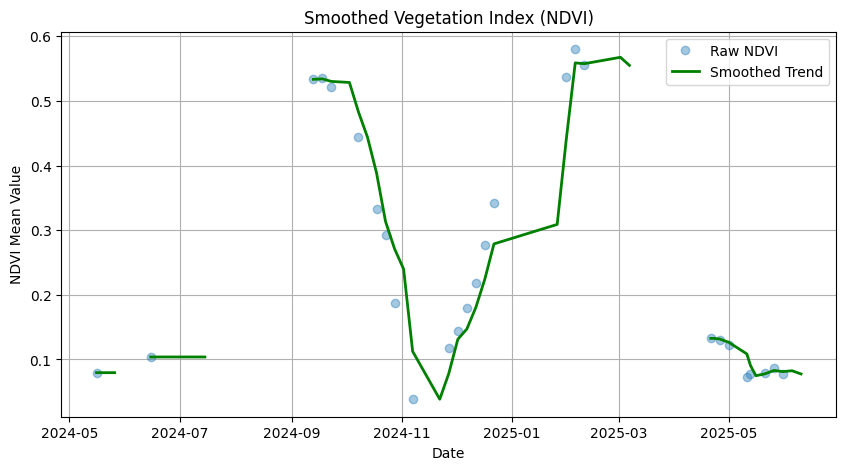

In [11]:
# Calculate 30-day moving averages
smoothed_df = pivoted_df.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(10, 5))
if 'NDVI' in smoothed_df.columns:
    plt.plot(pivoted_df.index, pivoted_df['NDVI'], 'o', alpha=0.4, label='Raw NDVI')
    plt.plot(smoothed_df.index, smoothed_df['NDVI'], color='green', linewidth=2, label='Smoothed Trend')

plt.title('Smoothed Vegetation Index (NDVI)')
plt.xlabel('Date')
plt.ylabel('NDVI Mean Value')
plt.legend()
plt.grid(True)
plt.show()

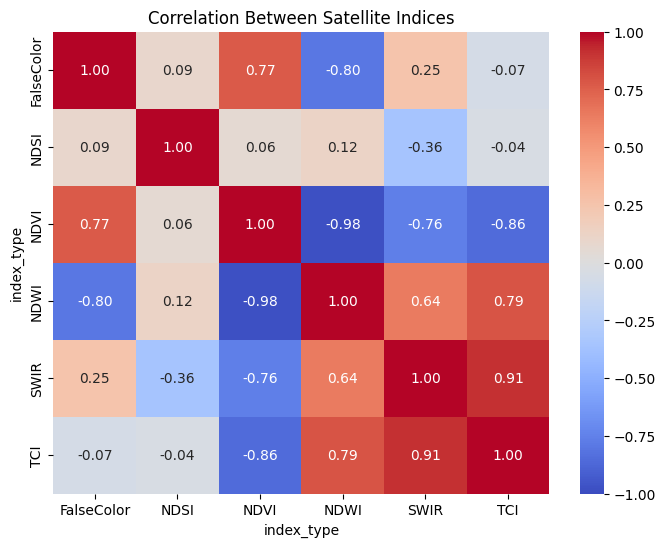

In [12]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(pivoted_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Between Satellite Indices')
plt.show()

In [13]:
import numpy as np

data = []

for filename in os.listdir('.'):
    if filename.endswith('.tif'):
        parts = filename.replace('.tif', '').split('_')
        if len(parts) >= 2:
            index_type = parts[0]
            date_str = parts[1].split('(')[0]

            with rasterio.open(filename) as src:
                # Read masked array to ignore nodata/invalid pixels
                arr = src.read(1, masked=True)

                # If array uses float, compute valid means
                mean_val = float(np.nanmean(arr)) if arr.size > 0 else np.nan
                max_val = float(np.nanmax(arr)) if arr.size > 0 else np.nan
                min_val = float(np.nanmin(arr)) if arr.size > 0 else np.nan

            data.append({
                'filename': filename,
                'index_type': index_type,
                'date': pd.to_datetime(date_str, errors='coerce'),
                'mean': mean_val,
                'min': min_val,
                'max': max_val
            })

df_raster = pd.DataFrame(data).dropna(subset=['date']).sort_values('date')

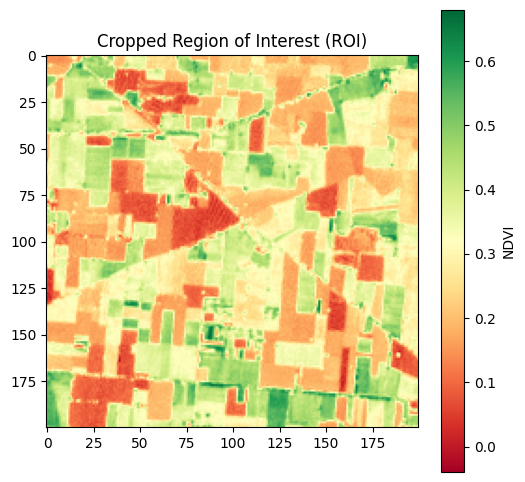

In [14]:
from rasterio.windows import Window

# Define pixel crop window: Window(col_off, row_off, width, height)
window = Window(50, 50, 200, 200)

with rasterio.open('NDVI_2024-10-23.tif') as src:
    subset = src.read(1, window=window)

plt.figure(figsize=(6, 6))
plt.imshow(subset, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('Cropped Region of Interest (ROI)')
plt.show()

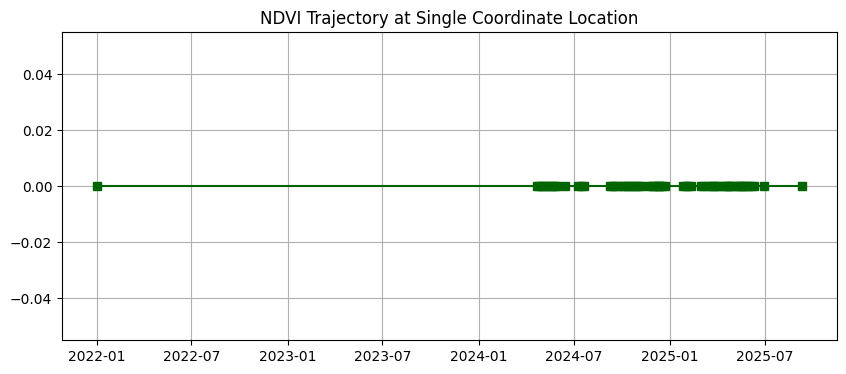

In [15]:
# Sample coordinates (X, Y in projected CRS EPSG:32643 from your metadata)
target_x, target_y = 700000.0, 1900000.0

point_data = []

for filename in os.listdir('.'):
    if filename.startswith('NDVI_') and filename.endswith('.tif'):
        date_str = filename.replace('NDVI_', '').replace('.tif', '').split('(')[0]

        with rasterio.open(filename) as src:
            # Sample value at coordinate point
            for val in src.sample([(target_x, target_y)]):
                point_data.append({
                    'date': pd.to_datetime(date_str),
                    'ndvi_point': val[0]
                })

df_point = pd.DataFrame(point_data).sort_values('date')

plt.figure(figsize=(10, 4))
plt.plot(df_point['date'], df_point['ndvi_point'], marker='s', color='darkgreen')
plt.title('NDVI Trajectory at Single Coordinate Location')
plt.grid(True)
plt.show()

In [16]:
import os
import rasterio
import numpy as np
import pandas as pd

records = []

# Loop through all .tif files in directory
for filename in os.listdir('.'):
    if filename.endswith('.tif'):
        parts = filename.replace('.tif', '').split('_')
        if len(parts) >= 2:
            index_type = parts[0]
            date_str = parts[1].split('(')[0] # clean up duplicate tags like (1)

            with rasterio.open(filename) as src:
                arr = src.read(1, masked=True)
                # Compute valid mean ignoring nodata values
                mean_val = float(np.nanmean(arr)) if arr.size > 0 else np.nan

            records.append({
                'date': pd.to_datetime(date_str, errors='coerce'),
                'index_type': index_type,
                'mean_value': mean_val
            })

# Create DataFrame and pivot into separate columns per index
df_all = pd.DataFrame(records).dropna(subset=['date'])
df_columns = df_all.pivot_table(
    index='date',
    columns='index_type',
    values='mean_value',
    aggfunc='mean'
).reset_index()

# Sort chronologically
df_columns = df_columns.sort_values('date')

# Display full table with all columns
df_columns.head(15)

index_type,date,FalseColor,NDSI,NDVI,NDWI,SWIR,TCI
0,2022-01-02,NaN,NaN,0.652606,NaN,NaN,NaN
1,2024-04-16,3530.989356,NaN,NaN,NaN,NaN,NaN
2,2024-04-21,3641.078675,-0.297205,0.125738,-0.221802,4279.204122,186.496080
3,2024-04-26,3996.267742,-0.310726,0.119377,-0.223981,4813.711007,217.421362
4,2024-05-01,3934.594514,-0.286739,0.116009,-0.208929,4642.141446,214.729424
5,2024-05-06,3622.107378,-0.295503,0.101882,-0.189468,4512.800204,197.246076
6,2024-05-11,3485.595619,-0.298956,0.105100,-0.195333,4309.183551,181.683778
7,2024-05-16,3294.665077,-0.256583,0.079508,-0.141977,4180.372788,183.742846
8,2024-05-21,3195.662857,-0.246285,0.084574,-0.143167,3956.805606,171.861407
9,2024-05-26,3248.212924,-0.247252,0.088179,-0.145202,4007.353180,174.887295


In [17]:
# Calculate descriptive statistics per index column
stats_df = df_columns.drop(columns=['date']).describe().T[['count', 'mean', 'std', 'min', 'max']]

# Format values to 4 decimal places
stats_df = stats_df.round(4)

print("="*65)
print(f"{'INDEX':<12} | {'COUNT':<6} | {'MEAN':<10} | {'STD':<10} | {'MIN':<8} | {'MAX':<8}")
print("="*65)

for idx, row in stats_df.iterrows():
    print(f"{idx:<12} | {int(row['count']):<6} | {row['mean']:<10.4f} | {row['std']:<10.4f} | {row['min']:<8.4f} | {row['max']:<8.4f}")

print("="*65)

INDEX        | COUNT  | MEAN       | STD        | MIN      | MAX     
FalseColor   | 59     | 3700.4433  | 998.0398   | 1036.1094 | 5709.8445
NDSI         | 58     | -0.2288    | 0.0629     | -0.3554  | -0.0267 
NDVI         | 59     | 0.2595     | 0.1878     | 0.0384   | 0.6526  
NDWI         | 58     | -0.2789    | 0.1402     | -0.5577  | -0.0537 
SWIR         | 58     | 3316.1200  | 1028.5544  | 654.1636 | 5122.2526
TCI          | 58     | 125.6005   | 68.2773    | 10.0280  | 254.9923


In [18]:
file_info = []

for filename in sorted(os.listdir('.')):
    if filename.endswith('.tif'):
        with rasterio.open(filename) as src:
            file_info.append({
                'Filename': filename,
                'Width': src.width,
                'Height': src.height,
                'Bands': src.count,
                'CRS': str(src.crs),
                'Data Type': src.dtypes[0]
            })

df_files = pd.DataFrame(file_info)

# Render formatted Colab table
display(df_files.head(20))

,Filename,Width,Height,Bands,CRS,Data Type
0,FalseColor_2024-04-16.tif,317,334,3,EPSG:32643,uint16
1,FalseColor_2024-04-21.tif,317,334,3,EPSG:32643,uint16
2,FalseColor_2024-04-26.tif,317,334,3,EPSG:32643,uint16
3,FalseColor_2024-05-01.tif,317,334,3,EPSG:32643,uint16
4,FalseColor_2024-05-06.tif,317,334,3,EPSG:32643,uint16
5,FalseColor_2024-05-11.tif,317,334,3,EPSG:32643,uint16
6,FalseColor_2024-05-16.tif,317,334,3,EPSG:32643,uint16
7,FalseColor_2024-05-21.tif,317,334,3,EPSG:32643,uint16
8,FalseColor_2024-05-26.tif,317,334,3,EPSG:32643,uint16
9,FalseColor_2024-05-31.tif,317,334,3,EPSG:32643,uint16


In [19]:
# Identify potential cloud cover, drought, or extreme vegetation growth dates
for col in ['NDVI', 'NDWI', 'SWIR']:
    if col in pivoted_df.columns:
        highest_date = pivoted_df[col].idxmax()
        lowest_date = pivoted_df[col].idxmin()
        print(f"--- {col} Extremes ---")
        print(f"Peak Value  : {pivoted_df[col].max():.4f} on {highest_date.strftime('%Y-%m-%d')}")
        print(f"Lowest Value: {pivoted_df[col].min():.4f} on {lowest_date.strftime('%Y-%m-%d')}\n")

--- NDVI Extremes ---
Peak Value  : 0.5799 on 2025-02-05
Lowest Value: 0.0384 on 2024-11-07

--- NDWI Extremes ---
Peak Value  : -0.0537 on 2024-11-07
Lowest Value: -0.5255 on 2025-02-05

--- SWIR Extremes ---
Peak Value  : 5122.2526 on 2025-05-01
Lowest Value: 654.1636 on 2025-09-10



In [20]:
# Compute date differences in days and value differences
diff_df = pivoted_df.copy()
diff_df['days_elapsed'] = diff_df.index.to_series().diff().dt.days

# Daily rate of change for NDVI
if 'NDVI' in diff_df.columns:
    diff_df['NDVI_daily_change'] = diff_df['NDVI'].diff() / diff_df['days_elapsed']

print("Daily Rate of Change (Top 10 Fastest Growth Dates):")
display(diff_df[['days_elapsed', 'NDVI_daily_change']].sort_values(by='NDVI_daily_change', ascending=False).head(10))

Daily Rate of Change (Top 10 Fastest Growth Dates):


index_type,days_elapsed,NDVI_daily_change
date,,
2024-12-22,5.0,0.012989
2024-12-17,5.0,0.011594
2025-02-05,5.0,0.008454
2024-12-12,5.0,0.007849
2024-12-07,5.0,0.006983
2024-12-02,5.0,0.005261
2025-05-13,2.0,0.002189
2025-05-26,5.0,0.001790
2024-09-18,5.0,0.000315


In [21]:
def classify_health(ndvi_val):
    if pd.isna(ndvi_val):
        return "Unknown/Masked"
    elif ndvi_val < 0.2:
        return "Bare Soil / Water"
    elif ndvi_val < 0.5:
        return "Moderate Vegetation"
    else:
        return "Dense / Healthy Crop"

if 'NDVI' in pivoted_df.columns:
    classified_series = pivoted_df['NDVI'].apply(classify_health)
    print("Distribution of Vegetation Health Days:")
    print(classified_series.value_counts())

Distribution of Vegetation Health Days:
NDVI
Unknown/Masked          32
Bare Soil / Water       15
Dense / Healthy Crop     6
Moderate Vegetation      6
Name: count, dtype: int64
